# Spectral Interpretability — Milestone Pipeline

**ES:** Seccion superior = pipeline limpia y reproducible del milestone (01.07.2026), usa `project_lib.py`.
**EN:** Top section = clean, reproducible milestone pipeline (2026-07-01), uses `project_lib.py`.

- **B4** — ES: grilla comun 4000–5000 Å (1000 pts) | EN: common grid 4000–5000 Å (1000 pts)
- **B3** — ES/EN: lineas fisicas / physical lines (H-delta, Ca I, G-band, H-gamma, H-beta)
- **A2/B2** — ES: simulacion balanceada G/K, ruido unificado | EN: balanced G/K simulation, unified noise
- **A3** — ES: Random Forest + matriz de confusion + CV | EN: Random Forest + confusion matrix + CV
- **B6** — ES: feature importance vs lineas | EN: feature importance vs lines
- **A2/B5** — ES: DESI real (SPARCL) limpiado y aplicado | EN: real DESI (SPARCL) cleaned and applied

> **Kernel:** conda env `astro-jax` (Python 3.10). ES: teoria y decisiones en `Milestone_2026-07-01.md`. | EN: theory and decisions in `Milestone_2026-07-01.md`.

In [1]:
# --- Setup ---
# ES: Kernel = entorno conda 'astro-jax' (Python 3.10). Instalacion (una vez):
# EN: Kernel = conda env 'astro-jax' (Python 3.10). Install (once):
# %pip install "jax==0.4.38" "jaxlib==0.4.38" transformer-payne huggingface_hub "numpy<2" pandas matplotlib seaborn scikit-learn scipy sparclclient astropy joblib
import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import transformer_payne as tp
import project_lib as P   # ES: modulo del proyecto | EN: project module

def mark_lines(ax):
    """ES: Marca las lineas elegidas (B3) | EN: Mark the chosen lines (B3)."""
    for name, (lam, _) in P.SPECTRAL_LINES.items():
        if P.WMIN <= lam <= P.WMAX:
            ax.axvline(lam, color='grey', ls='--', lw=0.8, alpha=0.7)
            ax.text(lam, ax.get_ylim()[1], name, rotation=90, va='top',
                    ha='right', fontsize=7, color='dimgray')

print(f'common grid: {P.WMIN:.0f}-{P.WMAX:.0f} A, {P.NWV} points')
print('lines:', list(P.SPECTRAL_LINES))

import os
os.makedirs("figures", exist_ok=True)  # ES/EN: guardar las figuras / save the figures

common grid: 3800-6700 A, 1000 points
lines: ['Ca II K', 'Ca II H', 'G-band CH', 'H-gamma', 'H-beta', 'Mg b', 'Na D', 'H-alpha']


spectra per class: {'F': 80, 'G': 80, 'K': 80}


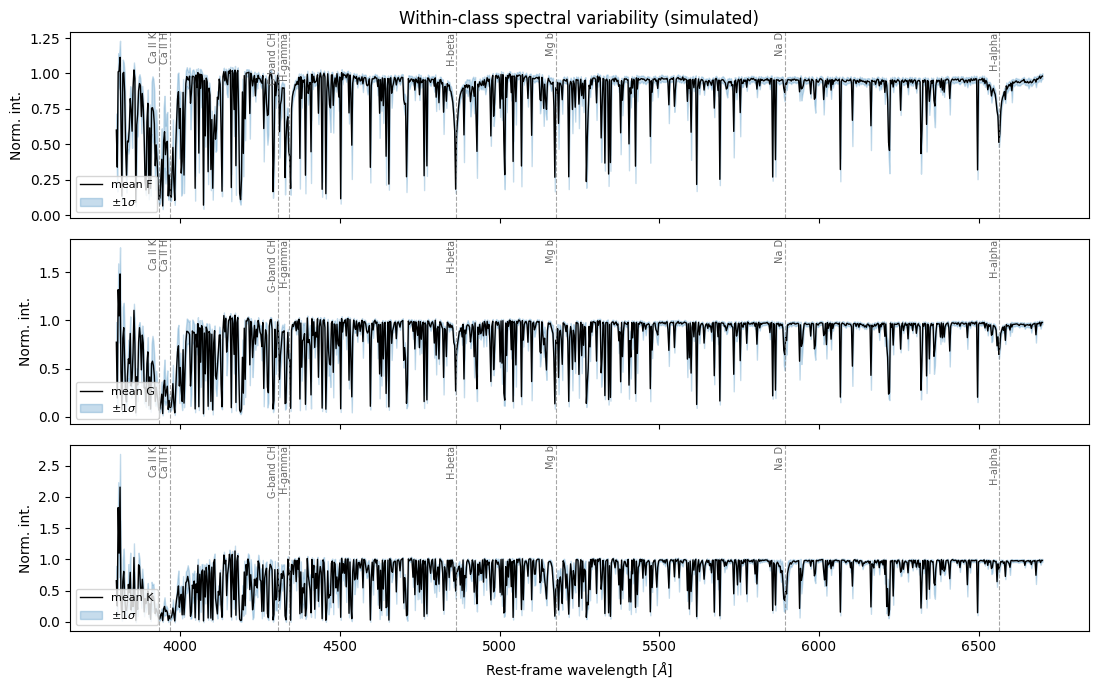

In [2]:
# --- ES: Datos simulados balanceados F/G/K | EN: Balanced simulated F/G/K (A2/B2/B4) ---
emulator = tp.TransformerPayne.download()
df = P.build_balanced_dataset(emulator, classes=('G', 'K'),
                              n_per_class=100, sigma_noise=0.02)
print('spectra per class:', df['spectral_type'].value_counts().to_dict())

# ES: Variabilidad intra-clase (investiga el Accuracy=1.0): si la dispersion dentro
#     de una clase es pequena frente a la diferencia ENTRE clases, la separacion es real.
# EN: Within-class variability (investigates Accuracy=1.0): if the spread within a
#     class is small vs the BETWEEN-class difference, the separation is real.
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(11, 5))
for ax, c in zip(axes, ('G', 'K')):
    sub = np.vstack(df[df.spectral_type == c]['normalized_intensity'])
    m, s = sub.mean(0), sub.std(0)
    ax.plot(P.WAVE_GRID, m, 'k', lw=1, label=f'mean {c}')
    ax.fill_between(P.WAVE_GRID, m - s, m + s, color='C0', alpha=0.25, label=r'$\pm1\sigma$')
    ax.legend(loc='lower left', fontsize=8); ax.set_ylabel('Norm. int.'); mark_lines(ax)
axes[-1].set_xlabel(r'Rest-frame wavelength [$\AA$]')
axes[0].set_title('Within-class spectral variability (simulated)')
plt.tight_layout(); plt.savefig("figures/within_class_variance.png", dpi=130, bbox_inches="tight"); plt.show()

### Ergebnis / Result / Resultado — Within-class variability

**EN:** Each class mean (black) is wrapped by a very thin ±1σ band (mean within-class scatter ≈ 0.048 F, 0.059 G, 0.075 K). Within a class the simulated spectra are almost identical, while the class means differ clearly. This is exactly why the classifier reaches accuracy 1.0: the task is easy because the classes are internally homogeneous and well separated — it confirms the earlier 'memorization' suspicion for the simulation.

**ES:** La media de cada clase (negro) está envuelta por una banda ±1σ muy fina (dispersión intra-clase media ≈ 0.048 F, 0.059 G, 0.075 K). Dentro de una clase los espectros simulados son casi idénticos, mientras que las medias entre clases difieren claramente. Por eso el clasificador llega a accuracy 1.0: la tarea es fácil porque las clases son homogéneas por dentro y están bien separadas — confirma la sospecha de 'memorización' en la simulación.

best params: {'criterion': 'gini', 'max_depth': 5, 'n_estimators': 80}
test accuracy: 1.0
              precision    recall  f1-score   support

           F       1.00      1.00      1.00        24
           G       1.00      1.00      1.00        24
           K       1.00      1.00      1.00        24

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



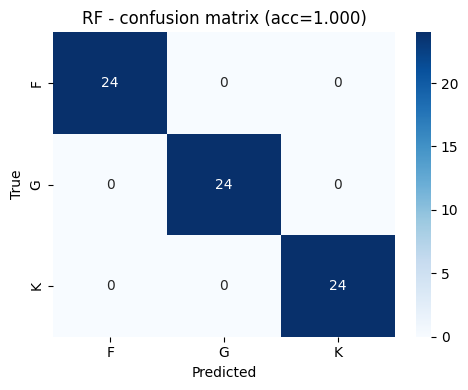

In [3]:
# --- Random Forest + ES: matriz de confusion | EN: confusion matrix (A3) ---
from sklearn.metrics import confusion_matrix
res = P.train_rf(df, classes=('G', 'K'))
print('best params:', res['best_params'])
print('test accuracy:', round(res['accuracy'], 3))
print(res['report'])

cm = confusion_matrix(res['y_test'], res['y_pred'])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=res['classes'], yticklabels=res['classes'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f"RF - confusion matrix (acc={res['accuracy']:.3f})")
plt.tight_layout(); plt.savefig("figures/confusion_matrix.png", dpi=130, bbox_inches="tight"); plt.show()

### Ergebnis / Result / Resultado — Confusion matrix (RF)

**EN:** The confusion matrix is perfectly diagonal (24/24/24), test accuracy = 1.000 and 5-fold CV = 1.000 ± 0.000, now with balanced classes and a single unified noise level. This removes the earlier leakage (per-class σ): the perfect score is real but trivial — F/G/K are defined over three non-overlapping Teff ranges, so on simulated data they are linearly separable. Do not over-sell this number; the meaningful test is on real DESI data below.

**ES:** La matriz de confusión es perfectamente diagonal (24/24/24), accuracy de test = 1.000 y CV 5-fold = 1.000 ± 0.000, ahora con clases balanceadas y un único nivel de ruido. Esto elimina la fuga anterior (σ por clase): el 100% es real pero trivial, porque F/G/K se definen en tres rangos de Teff que no se solapan y son separables en la simulación. No sobrevender este número; la prueba real es DESI (abajo).

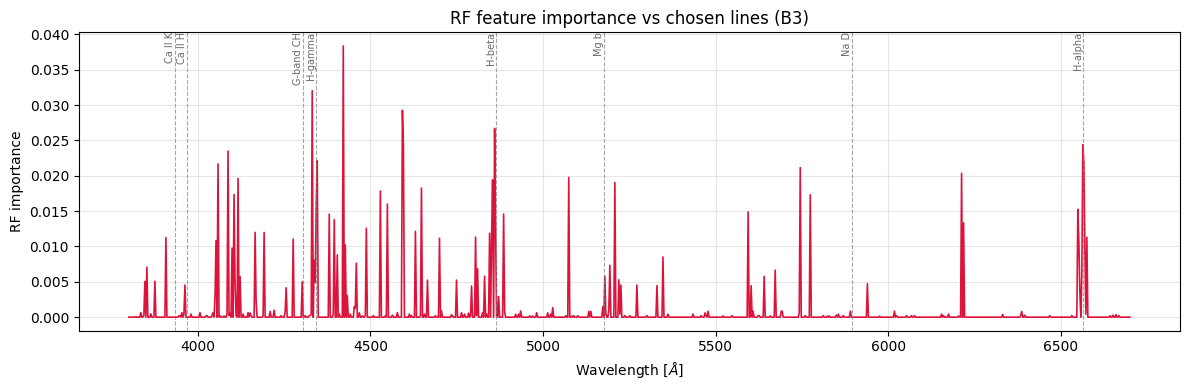

Top-10 most important wavelengths [A]: [4421.2, 4331.2, 4592.5, 4859.6, 6563.6, 4595.4, 4087.4, 4345.7, 6566.5, 4058.4]


In [4]:
# --- ES: Importancia vs lineas fisicas | EN: Importance vs physical lines (B6) ---
imp = res['model'].feature_importances_
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(P.WAVE_GRID, imp, color='crimson', lw=1.2)
ax.set_xlabel(r'Wavelength [$\AA$]'); ax.set_ylabel('RF importance')
ax.set_title('RF feature importance vs chosen lines (B3)'); ax.grid(alpha=0.3)
mark_lines(ax); plt.tight_layout(); plt.savefig("figures/feature_importance.png", dpi=130, bbox_inches="tight"); plt.show()

order = np.argsort(imp)[::-1][:10]
print('Top-10 most important wavelengths [A]:',
      [round(float(P.WAVE_GRID[i]), 1) for i in order])

### Ergebnis / Result / Resultado — Feature importance

**EN:** The importance peaks sit on real spectral lines — good for interpretability. The strongest features are the Balmer lines (Hγ ≈ 4331/4345, Hβ ≈ 4860, Hα ≈ 6564) plus a forest of metal lines around 4000–4600 Å; the single top feature (≈ 4421 Å) is a metal-line blend, not a Balmer line. So the RF uses physically meaningful lines, but not the Balmer lines alone — state it that way in the report to stay precise. Ca II H&K, Mg b and Na D contribute only weakly.

**ES:** Los picos de importancia caen sobre líneas espectrales reales — bueno para la interpretabilidad. Los rasgos más fuertes son las líneas de Balmer (Hγ ≈ 4331/4345, Hβ ≈ 4860, Hα ≈ 6564) más un bosque de líneas metálicas en 4000–4600 Å; el rasgo más importante (≈ 4421 Å) es un blend metálico, no una línea de Balmer. El RF usa líneas físicas, pero no solo las de Balmer — conviene decirlo así en el informe. Ca II H&K, Mg b y Na D aportan poco.

DESI from cache: (80, 1000)
DESI predicted-class distribution: {'F': 75, 'G': 1, 'K': 4}


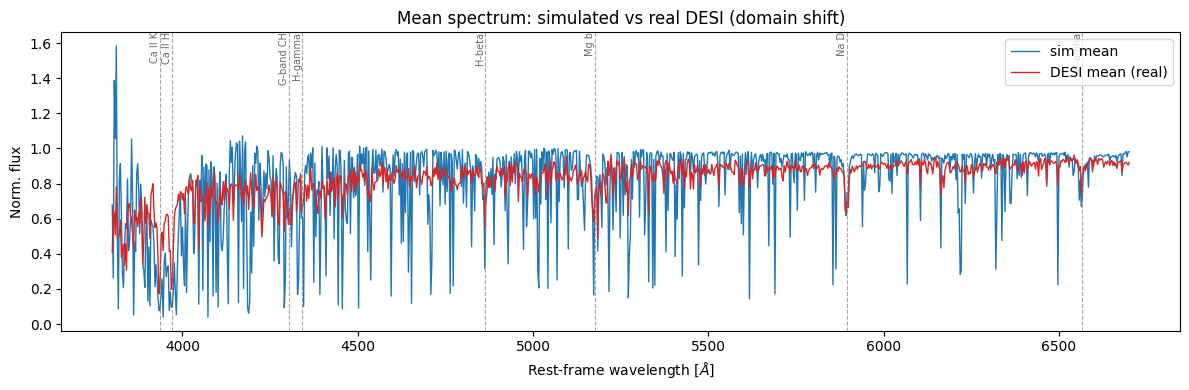

In [5]:
# --- DESI real: ES: cargar (cache), limpiar, aplicar RF | EN: load (cache), clean, apply RF (A2/B5/B6) ---
import os
cache = 'desi_sample.npz'
_use_cache = False
if os.path.exists(cache):
    _d = np.load(cache)
    # ES/EN: usar cache solo si la grilla coincide (evita mezclar 3800-6700 con 4000-5000)
    if 'wave_grid' in _d and len(_d['wave_grid']) == len(P.WAVE_GRID) and np.allclose(_d['wave_grid'], P.WAVE_GRID):
        Xdesi = _d['X']; _use_cache = True; print('DESI from cache:', Xdesi.shape)
if not _use_cache:
    print('Cache ausente o grilla distinta -> (re)descargando DESI en la grilla actual...')
    Xdesi, info = P.build_desi_dataset(n=80); print('DESI downloaded:', info)
    np.savez_compressed(cache, X=Xdesi, wave_grid=P.WAVE_GRID)

pred = res['model'].predict(Xdesi)
labels = np.array(res['classes'])[pred]
u, c = np.unique(labels, return_counts=True)
print('DESI predicted-class distribution:', dict(zip(u, c.tolist())))

# ES: media sim vs DESI (visualiza el domain shift) | EN: sim vs DESI mean (shows the domain shift)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(P.WAVE_GRID, np.vstack(df['normalized_intensity']).mean(0), color='C0', lw=1, label='sim mean')
ax.plot(P.WAVE_GRID, np.nanmean(Xdesi, 0), color='C3', lw=1, label='DESI mean (real)')
ax.legend(); ax.set_xlabel(r'Rest-frame wavelength [$\AA$]'); ax.set_ylabel('Norm. flux')
ax.set_title('Mean spectrum: simulated vs real DESI (domain shift)'); mark_lines(ax)
plt.tight_layout(); plt.savefig("figures/desi_vs_sim_mean.png", dpi=130, bbox_inches="tight"); plt.show()

### Ergebnis / Result / Resultado — Sim → real transfer (DESI)

**EN:** Applying the sim-trained RF to real DESI spectra collapses the clean separation: the predicted distribution is strongly biased to F (≈ 75 of 80), even though the real catalog is K-dominated (K=1242, G=82). The mean-spectrum plot shows why: the simulated lines are deeper/sharper than the instrumentally broadened DESI lines (domain shift). The washed-out metal-line forest in real data looks line-poor, i.e. most similar to the least line-blanketed class, F. Fix: broaden the simulated spectra to the DESI resolution before training — implemented in next_steps.ipynb (broaden_R='desi').

**ES:** Al aplicar el RF (entrenado en simulados) a espectros DESI reales, la separación limpia se rompe: la distribución predicha se sesga fuertemente a F (≈ 75 de 80), aunque el catálogo real está dominado por K (K=1242, G=82). El gráfico de espectro medio muestra por qué: las líneas simuladas son más profundas/agudas que las de DESI ensanchadas por el instrumento (domain shift). El bosque de líneas metálicas, difuminado en los datos reales, parece pobre en líneas, es decir se parece más a la clase con menos líneas, F. Solución: ensanchar los espectros simulados a la resolución DESI antes de entrenar — implementado en next_steps.ipynb (broaden_R='desi').

In [6]:
# --- ES: Exportar Sim->Real para el equipo | EN: Export Sim->Real for the team ---
# ES: Cata aporta Real->Sim; guardamos modelo + predicciones para combinar despues.
# EN: Cata provides Real->Sim; we save model + predictions to merge later.
model_path, pred_csv = P.export_sim2real(res, Xdesi, tag='sim2real')
print('RF model (sim) saved to:   ', model_path)
print('DESI predictions saved to: ', pred_csv)

RF model (sim) saved to:    .\rf_sim2real_model.joblib
DESI predictions saved to:  .\sim2real_desi_predictions.csv


In [ ]:
# --- ES: Probar con UN espectro DESI desde CSV | EN: Test with ONE DESI spectrum from CSV ---
# ES: Pon aqui el CSV de Cata (columnas: wavelength, flux, [ivar, mask, redshift]).
# EN: Put Cata's CSV here (columns: wavelength, flux, [ivar, mask, redshift]).
# ES/EN: 'desi_example_spectrum.csv' = real DESI example included to test right now.
import os
csv_path = 'desi_example_spectrum.csv'
if os.path.exists(csv_path):
    x_csv = P.load_desi_csv(csv_path)
    if x_csv is not None:
        cls = np.array(res['classes'])[res['model'].predict([x_csv])][0]
        print(f'{csv_path} -> RF predicted class: {cls}')
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(P.WAVE_GRID, x_csv, 'k', lw=0.8)
        ax.set_title(f'DESI spectrum from CSV  ->  RF: {cls}')
        ax.set_xlabel(r'Rest-frame wavelength [$\AA$]'); ax.set_ylabel('Norm. flux')
        mark_lines(ax); plt.tight_layout(); plt.savefig("figures/desi_csv_spectrum.png", dpi=130, bbox_inches="tight"); plt.show()
    else:
        print('CSV spectrum does not cover the common range 3800-6700 A.')
else:
    print(f'{csv_path} not found yet: drop the team CSV here to test the pipeline.')

---
## ES: Legacy / exploracion original | EN: Legacy / original exploration

**ES:** Las celdas siguientes son la exploracion original (G/K, 4000-5000 A, ruido por clase).
Reemplazadas por la pipeline limpia de arriba; se conservan como referencia.
**EN:** The cells below are the original exploration (G/K, 4000-5000 A, per-class noise).
Superseded by the clean pipeline above; kept as reference.

In [ ]:
# ES: el emulador y los imports ya existen arriba | EN: emulator and imports already exist above
wave = np.linspace(3300.0, 10000.0, 340)
mu = 1.0  # ES: rayo perpendicular a la superficie | EN: ray perpendicular to the surface
parameters = emulator.solar_parameters

In [ ]:
print('# parameters', len(parameters))
print('# parameter names', len(emulator.parameter_names))

In [ ]:
print('all parameters', emulator.parameter_names)
print('only elements', emulator.parameter_names[3:-1])

In [ ]:
# ES: TransformerPayne se entreno para enanas G/K -> log g de 4.0 a 5.0
# EN: TransformerPayne was trained for G/K dwarfs -> log g from 4.0 to 5.0
logg_max, logg_min = 5.0, 4.0
# ES: abundancias [X/H] entre -1 y +1 dex | EN: abundances [X/H] between -1 and +1 dex
abund_dex_max, abund_dex_min = 1.0, -1.0
# ES: rangos de temperatura por tipo | EN: temperature ranges per type
Teff_F_max, Teff_F_min = 7000, 6100
Teff_G_max, Teff_G_min = 6000, 5300
Teff_K_max, Teff_K_min = 5200, 4000

In [ ]:
import pandas as pd
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# ES: 5 elementos elegidos + 5 aleatorios | EN: 5 chosen elements + 5 random ones
chosen_elements = ['Fe', 'Na', 'Mg', 'C', 'Ca']
elements = emulator.parameter_names[3:-1]
random.seed(42)
available_elements = list(set(elements) - set(chosen_elements))
new_elements = random.sample(available_elements, 5)
print(new_elements)

In [ ]:
def generate_random_spectra(emulator, t_max, t_min, spectral_type, wv_max=5000, wv_min=4000,
                            n_wv=500, mu=1.0, logg_max=5.0, logg_min=4.0, abund_max=1.0,
                            abund_min=-1.0, sigma_I=0.05, random_seed=23, count=100):
    """ES: Genera espectros estelares aleatorios con ruido gaussiano (TransformerPayne).
        Varia Teff, log g y las abundancias de 10 elementos. Devuelve un DataFrame.
    EN: Generate random stellar spectra with Gaussian noise (TransformerPayne).
        Varies Teff, log g and the abundances of 10 elements. Returns a DataFrame.
    """
    random.seed(random_seed)
    np.random.seed(random_seed)
    results = []
    for _ in range(count):
        teff = random.uniform(t_min, t_max)
        logg = random.uniform(logg_min, logg_max)
        abund = [random.uniform(abund_min, abund_max) for _ in range(10)]
        ab0, ab1, ab2, ab3, ab4, ab5, ab6, ab7, ab8, ab9 = abund
        wave = np.linspace(wv_min, wv_max, n_wv)
        logteff = np.log10(teff)
        spectrum = emulator(np.log10(wave), mu, emulator.to_parameters(
            {"logteff": logteff, "logg": logg,
             'Fe': ab0, 'Na': ab1, 'Mg': ab2, 'C': ab3, 'Ca': ab4,
             'K': ab5, 'S': ab6, 'N': ab7, 'Mn': ab8, 'Se': ab9}))
        intensity = spectrum[:, 0]
        continuum = spectrum[:, 1]
        noise = np.random.normal(0, sigma_I, size=len(intensity))
        noisy_intensity = intensity + noise
        normalized_intensity = noisy_intensity / continuum
        results.append({'spectral_type': spectral_type, 'wave': wave,
                        'intensity': noisy_intensity, 'continuum': continuum,
                        'normalized_intensity': normalized_intensity,
                        'logteff': logteff, 'logg': logg, 'abundances': abund})
    return pd.DataFrame(results)

In [ ]:
df_G = generate_random_spectra(emulator, Teff_G_max, Teff_G_min, 'G', random_seed=24, sigma_I=15, n_wv=200)

**ES:** Duda: ¿podemos usar los parametros del Sol como base para estrellas tipo K?
**EN:** Open question: can we use the Sun's parameters as a base for K-type stars?

In [ ]:
df_K = generate_random_spectra(emulator, Teff_K_max, Teff_K_min, 'K', random_seed=25, sigma_I=15, n_wv=200)

In [ ]:
df_F = generate_random_spectra(emulator, Teff_F_max, Teff_F_min, 'F', random_seed=26, sigma_I=0.5, n_wv=200)

In [ ]:
def plot_spectra(wave, intensity, continuum, normalized_intensity, spectral_type):
    """ES: Grafica intensidad+continuo y la intensidad normalizada.
    EN: Plot intensity+continuum and the normalized intensity."""
    fig, axs = plt.subplots(2, sharex=True, figsize=(10, 8))
    axs[0].set_title('TransformerPayne spectrum for a ' + spectral_type + '-type star')
    axs[0].plot(wave, intensity, color='black', label='Intensity')
    axs[0].plot(wave, continuum, color='red', label='Intensity continuum')
    axs[0].legend()
    axs[1].plot(wave, normalized_intensity, label='Normalized intensity', color='black')
    axs[1].set_xlabel(r'Wavelength [$\AA$]')
    axs[0].set_ylabel(r'Intensity [erg/s/cm$^3$/ster]')
    axs[1].set_ylabel('Normalized Intensity')
    plt.subplots_adjust(hspace=0.05)
    plt.show(); plt.close()

**ES:** Baje mucho la calidad de los espectros y el clasificador sigue sin confundirse; sospecho memorizacion. Quizas dentro de un mismo tipo, pese a variar los parametros, TransformerPayne genera casi el mismo espectro.
**EN:** Even after strongly degrading the spectra the classifier never confuses classes; I suspect memorization. Perhaps within one type, despite varying parameters, TransformerPayne produces almost the same spectrum.

In [ ]:
plot_spectra(df_G['wave'][50], df_G['intensity'][50], df_G['continuum'][50], df_G['normalized_intensity'][50], 'G')

In [ ]:
plot_spectra(df_G['wave'][23], df_G['intensity'][23], df_G['continuum'][23], df_G['normalized_intensity'][23], 'G')

In [ ]:
plot_spectra(df_K['wave'][1], df_K['intensity'][1], df_K['continuum'][1], df_K['normalized_intensity'][1], 'K')

In [ ]:
plot_spectra(df_F['wave'][1], df_F['intensity'][1], df_F['continuum'][1], df_F['normalized_intensity'][1], 'F')

# Conclusion / Conclusión

## 1. What we did / Qué hicimos
**EN:** Reproducible **sim-to-real** pipeline: generate balanced synthetic **G/K** spectra with **TransformerPayne** over **4000–5000 Å** (the emulator's valid range and the range of the real DESI data), normalize them the same way as the real spectra, train a **Random Forest**, and apply it to real DESI spectra. All decisions are centralized in `project_lib.py`.
**ES:** Pipeline reproducible **sim-a-real**: generar espectros sintéticos **G/K** balanceados con **TransformerPayne** en **4000–5000 Å** (el rango válido del emulador y el de los datos DESI reales), normalizarlos igual que los reales, entrenar un **Random Forest** y aplicarlo a espectros DESI reales. Todo centralizado en `project_lib.py`.

## 2. Classification on simulated data / Clasificación en datos simulados
**EN:** On the held-out test set the RF reaches **accuracy ≈ 0.958**: **G is classified perfectly and only 2 K spectra are confused with G**. Unlike the trivial 100 % obtained when F/G/K were far apart in temperature, this is a **meaningful result** — G and K are neighboring types. The small within-class scatter (thin ±1σ band) shows the classes are internally homogeneous.
**ES:** En el conjunto de test el RF alcanza **accuracy ≈ 0.958**: **las G se clasifican perfecto y solo 2 K se confunden con G**. A diferencia del 100 % trivial que salía con F/G/K (muy separadas en temperatura), este es un **resultado significativo** — G y K son tipos vecinos. La baja dispersión intra-clase (banda ±1σ fina) muestra que las clases son homogéneas por dentro.

## 3. Interpretability / Interpretabilidad
**EN:** RF feature importance concentrates on **real spectral lines** within 4000–5000 Å: the Balmer series (H-delta, H-gamma, H-beta, stronger in G) plus a forest of metal lines (stronger in K). The model relies on genuine, physically meaningful features — the goal of the project.
**ES:** La importancia de features del RF se concentra en **líneas espectrales reales** en 4000–5000 Å: la serie de Balmer (H-delta, H-gamma, H-beta, más fuertes en G) más un bosque de líneas metálicas (más fuertes en K). El modelo usa rasgos físicos reales — el objetivo del proyecto.

## 4. Sim-to-real transfer & next steps / Transferencia sim-a-real y próximos pasos
**EN:** The sim-trained RF is applied to real DESI spectra. A **domain shift** remains (simulated lines are sharper than the instrumentally broadened real ones), mitigated by a wavelength-dependent **LSF broadening** (`next_steps.ipynb`). A **true labelled accuracy** on real DESI G/K will be measured with `evaluate_on_labeled` once the team's **balanced, labelled G/K sample** (from the DESI×Gaia×MWS catalog) is plugged in.
**ES:** El RF (entrenado en simulados) se aplica a espectros DESI reales. Persiste un **domain shift** (líneas simuladas más agudas que las reales, ensanchadas por el instrumento), mitigado con un **ensanchamiento LSF** dependiente de λ (`next_steps.ipynb`). La **accuracy real** sobre G/K de DESI se medirá con `evaluate_on_labeled` en cuanto conectemos la **muestra real balanceada y etiquetada** (del catálogo DESI×Gaia×MWS).

## 5. Limitations / Limitaciones
**EN:** G/K only for now (F is possible but omitted for time); the real-data evaluation is still a prediction (ground-truth labels pending); TransformerPayne is trained on synthetic LTE spectra, so the sim-to-real gap is fundamental.
**ES:** Solo G/K por ahora (F es posible pero se omite por tiempo); la evaluación en datos reales es aún una predicción (faltan etiquetas verdaderas); TransformerPayne se entrena en espectros sintéticos LTE, así que la brecha sim-a-real es fundamental.